## Part 2: Exporatory Data Analysis (EDA)

With all of the data loaded in, synced, merged and adjusted to represent what was known at the time rather than what the actual conditions were (there is often a delay here), we can now look at all of these together to get an idea for how they correlate.

In [9]:
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from macro_etf.common import PROCESSED_DATA_DIR, POINTS_OF_INTEREST

data_fn = "processed_market_data.csv"


### 2.0 Load data

In [10]:
df = pd.read_csv(PROCESSED_DATA_DIR / data_fn, index_col=0)
df.index = pd.to_datetime(df.index)

Quickly check the date to make sure that it still looks right

In [11]:
display(df.head(3))

,yield_spread,credit_spread,financial_stress,initial_claims,cpi,unemployment,fed_funds_rate,industrial_production,retail_sales,consumer_sentiment,...,job_openings,credit_card_delinquency,close_spy,close_qqq,close_vix,close_oil,volume_spy,volume_qqq,volume_oil,real_gdp
2001-02-28,0.51,2.88,0.437625,371250.0,175.6,4.2,5.49,91.9020,247339.0,94.7,...,5088.0,4.81,78.485298,39.983036,28.350000,27.420000,14825800.0,102187900.0,82364.0,14229.765
2001-03-31,0.75,3.04,0.675540,387200.0,176.0,4.2,5.31,91.3034,247289.0,90.6,...,5234.0,4.81,74.087158,32.989159,28.639999,26.400000,9183600.0,63661300.0,63947.0,14183.120
2001-04-30,1.05,2.73,0.800700,396750.0,176.1,4.3,4.80,91.1162,244514.0,91.5,...,5097.0,4.81,80.417152,38.887619,25.480000,28.459999,10766900.0,73859100.0,40223.0,14183.120


In [12]:
display(df.tail(3))


,yield_spread,credit_spread,financial_stress,initial_claims,cpi,unemployment,fed_funds_rate,industrial_production,retail_sales,consumer_sentiment,...,job_openings,credit_card_delinquency,close_spy,close_qqq,close_vix,close_oil,volume_spy,volume_qqq,volume_oil,real_gdp
2026-04-30,0.52,1.70,-0.575300,207750.0,330.293,4.3,3.64,101.6172,653772.0,53.3,...,6922.0,2.92,716.813293,667.006958,16.889999,105.070000,67240900.0,40622200.0,341994.0,24180.419
2026-05-31,0.47,1.57,-0.720980,211600.0,332.407,4.3,3.63,102.4196,657830.0,49.8,...,6887.0,2.92,754.536133,737.499512,15.320000,87.360001,55075700.0,37541700.0,267803.0,24180.419
2026-06-30,0.30,1.53,-0.808475,222500.0,333.979,4.3,3.63,102.5606,664439.0,44.8,...,7585.0,2.92,746.770020,736.400024,16.450001,69.500000,55626000.0,42121800.0,194279.0,24180.419


In [13]:
display(df.info())

<class 'pandas.DataFrame'>
DatetimeIndex: 305 entries, 2001-02-28 to 2026-06-30
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   yield_spread             305 non-null    float64
 1   credit_spread            305 non-null    float64
 2   financial_stress         305 non-null    float64
 3   initial_claims           305 non-null    float64
 4   cpi                      305 non-null    float64
 5   unemployment             305 non-null    float64
 6   fed_funds_rate           305 non-null    float64
 7   industrial_production    305 non-null    float64
 8   retail_sales             305 non-null    float64
 9   consumer_sentiment       305 non-null    float64
 10  personal_savings_rate    305 non-null    float64
 11  housing_starts           305 non-null    float64
 12  building_permits         305 non-null    float64
 13  m2                       305 non-null    float64
 14  job_openings      

None

In [14]:
display(df.describe())


,yield_spread,credit_spread,financial_stress,initial_claims,cpi,unemployment,fed_funds_rate,industrial_production,retail_sales,consumer_sentiment,...,job_openings,credit_card_delinquency,close_spy,close_qqq,close_vix,close_oil,volume_spy,volume_qqq,volume_oil,real_gdp
count,305.000000,305.00000,305.000000,3.050000e+02,305.000000,305.000000,305.000000,305.000000,305.000000,305.000000,...,305.000000,305.000000,305.000000,305.000000,305.000000,305.000000,3.050000e+02,3.050000e+02,3.050000e+02,305.000000
mean,1.099574,2.45777,0.011573,3.712375e+05,237.463892,5.684754,1.860459,97.494946,396347.298361,80.396721,...,5491.986885,3.382000,210.883753,151.321337,19.687672,65.702000,1.150043e+08,6.579276e+07,3.167407e+05,18501.159557
std,0.948623,0.75627,1.095655,3.279213e+05,41.781911,1.943318,1.868504,4.719343,116358.288972,13.572711,...,2276.317382,1.215597,169.123099,163.249294,7.860366,24.324550,7.893111e+07,4.208832e+07,2.060430e+05,2829.766033
min,-1.060000,1.42000,-1.102425,1.975000e+05,175.600000,3.400000,0.050000,84.561900,243130.000000,44.800000,...,2232.000000,1.530000,53.022808,17.459400,9.510000,18.840000,9.183600e+06,9.854600e+06,0.000000e+00,14183.120000
25%,0.280000,1.87000,-0.609620,2.352500e+05,206.755000,4.300000,0.140000,93.774900,308588.000000,70.500000,...,3768.000000,2.450000,83.923775,35.862930,14.020000,48.320000,6.290120e+07,3.648460e+07,1.540640e+05,16420.738000
50%,1.100000,2.31000,-0.299940,3.232000e+05,233.544000,5.000000,1.240000,99.099700,366243.000000,82.100000,...,4732.000000,3.060000,141.652832,74.666428,17.400000,65.870003,9.600740e+07,5.430900e+07,2.914080e+05,17860.450000
75%,1.910000,2.88000,0.283550,3.980000e+05,257.155000,6.300000,3.640000,101.036700,447774.000000,92.100000,...,6966.000000,4.210000,279.024658,204.671402,23.400000,81.930000,1.442994e+08,8.481080e+07,4.186280e+05,20602.275000
max,2.840000,6.10000,8.498240,4.663250e+06,333.979000,14.800000,5.490000,104.100400,664439.000000,103.800000,...,12301.000000,6.770000,754.536133,737.499512,59.889999,140.000000,4.705109e+08,2.602245e+08,1.311000e+06,24180.419000


The data looks good and ready to explore!

### 2.1 Univariate analysis

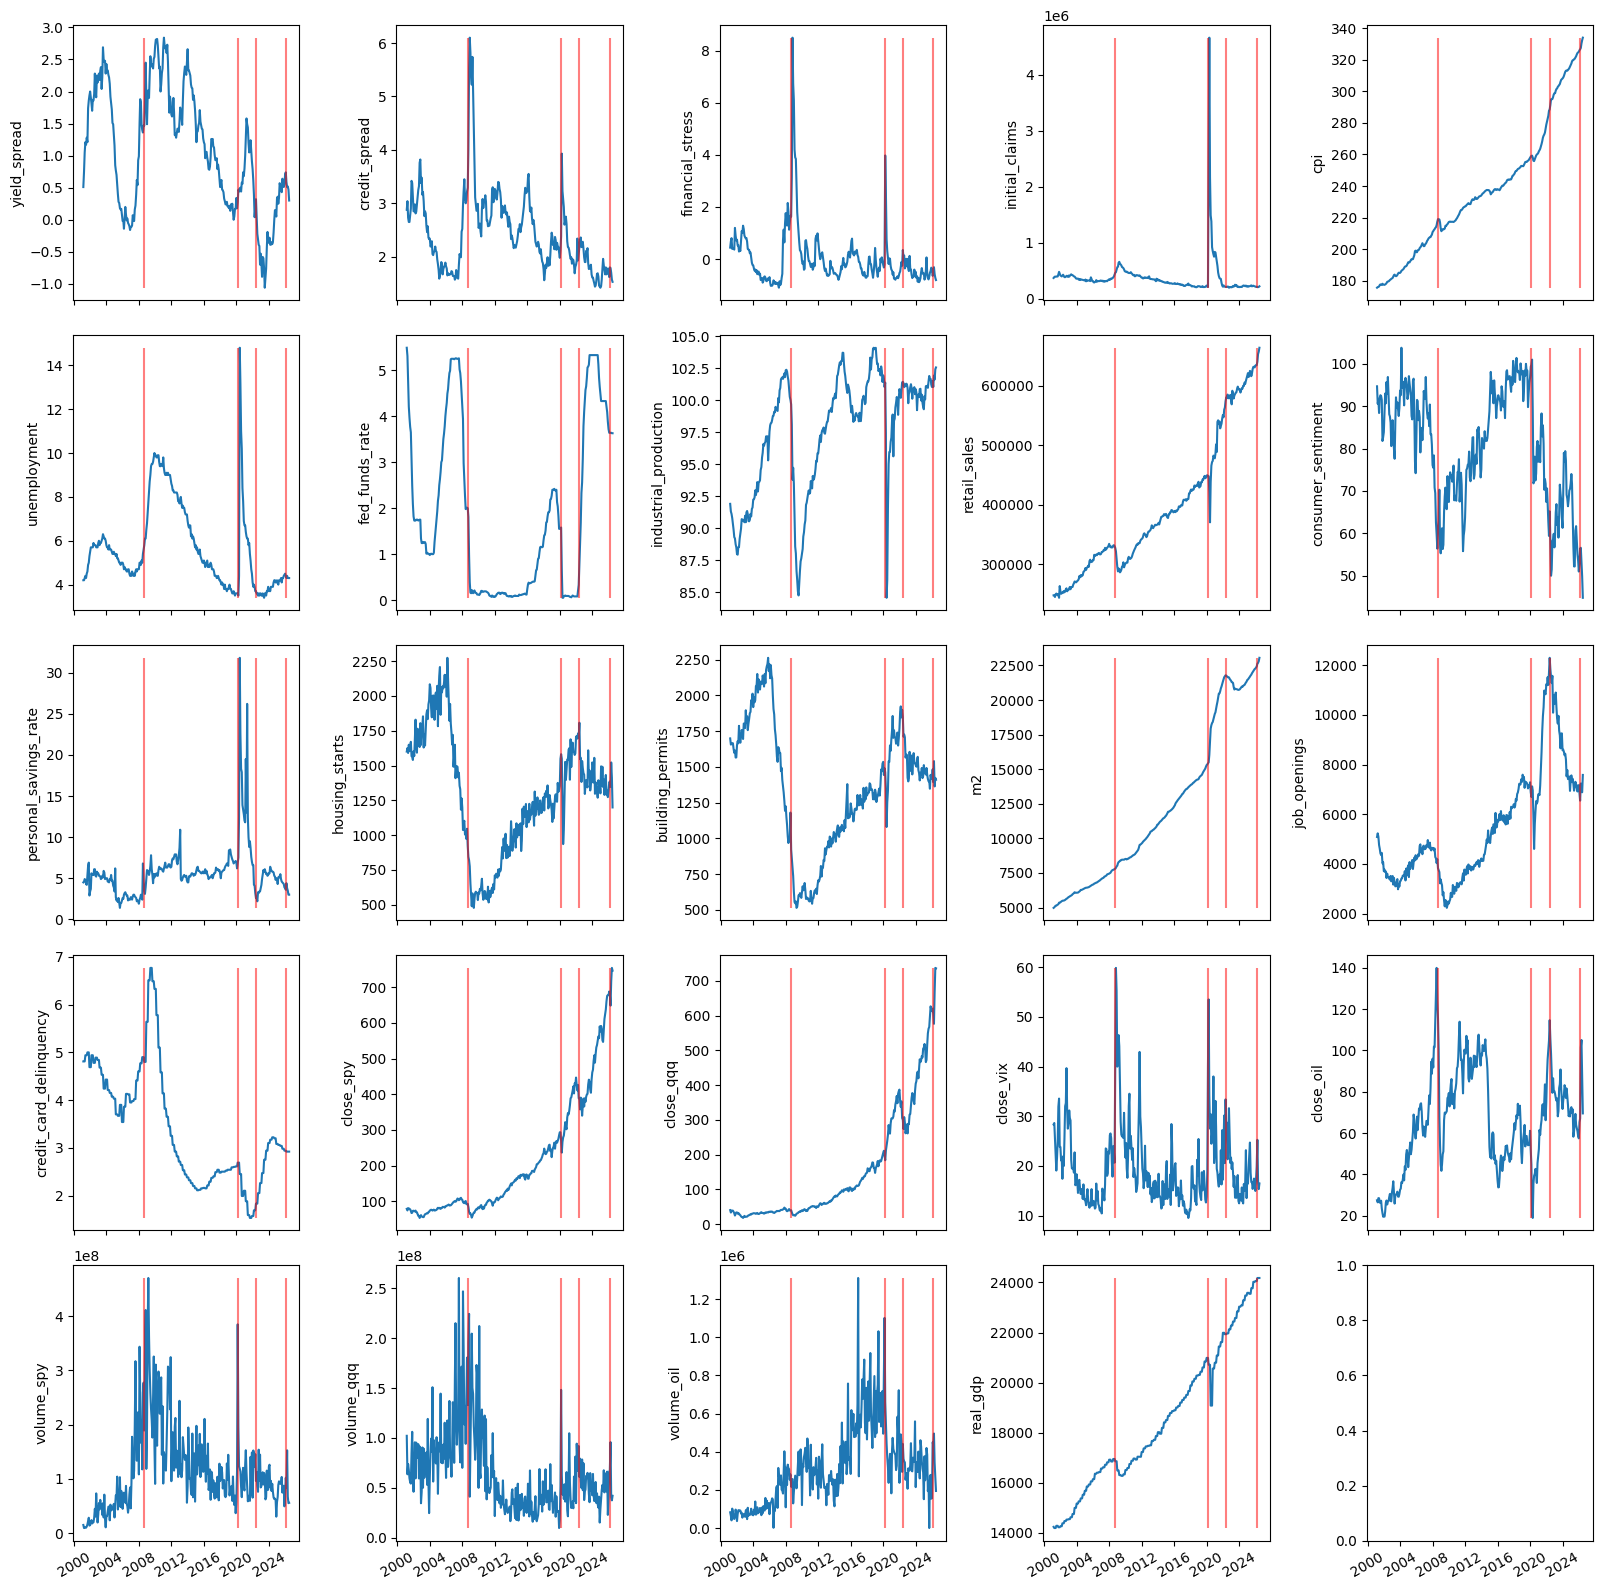

In [15]:
# Let's mark different important dates that are associated with big moves in the markets:
# These dates are saved in common.py

# Let's make some line plots for each feature
n_cols = int(np.ceil(np.sqrt(len(df.columns))))
n_rows = int(np.ceil(len(df.columns)/n_cols))
f, axs = plt.subplots(nrows=n_rows, ncols=n_cols, sharex=True, figsize=(16,16))
for i,col in enumerate(df.columns):
    ax = axs.flatten()[i]
    sns.lineplot(df[col], ax=ax)
    ax.vlines(POINTS_OF_INTEREST, df[col].min(), df[col].max(), color='r', linestyle="-", alpha=0.5)

for ax in axs.flatten():
    ax.tick_params(axis='x', rotation=30)


plt.tight_layout()

Overall, the lineplots for each feature are not overly surprising. 

The economic crises of 2008 and 2020 resulted in
- spikes in financial stress, unemployment, credit card delinquencies etc, 
- large drops in job opennings, consumer sentiment, building permits, etc. 

The Fed increasing the interest rates in 2022 resulted in a cooling economy which can be seen in:
- reduction the rate of change of cpi,
- unemployment ticking upwards,
- job opennings decreasing
- credit card delinquency increasing

The US-Iran war has occurred rather recently and so we cannot say much about long-term impacts, but so far we can see an initial drop in SPY and QQQ prices, an increase in VIX, and an increase in inflationary pressure. More time is needed to see longer-term impact.

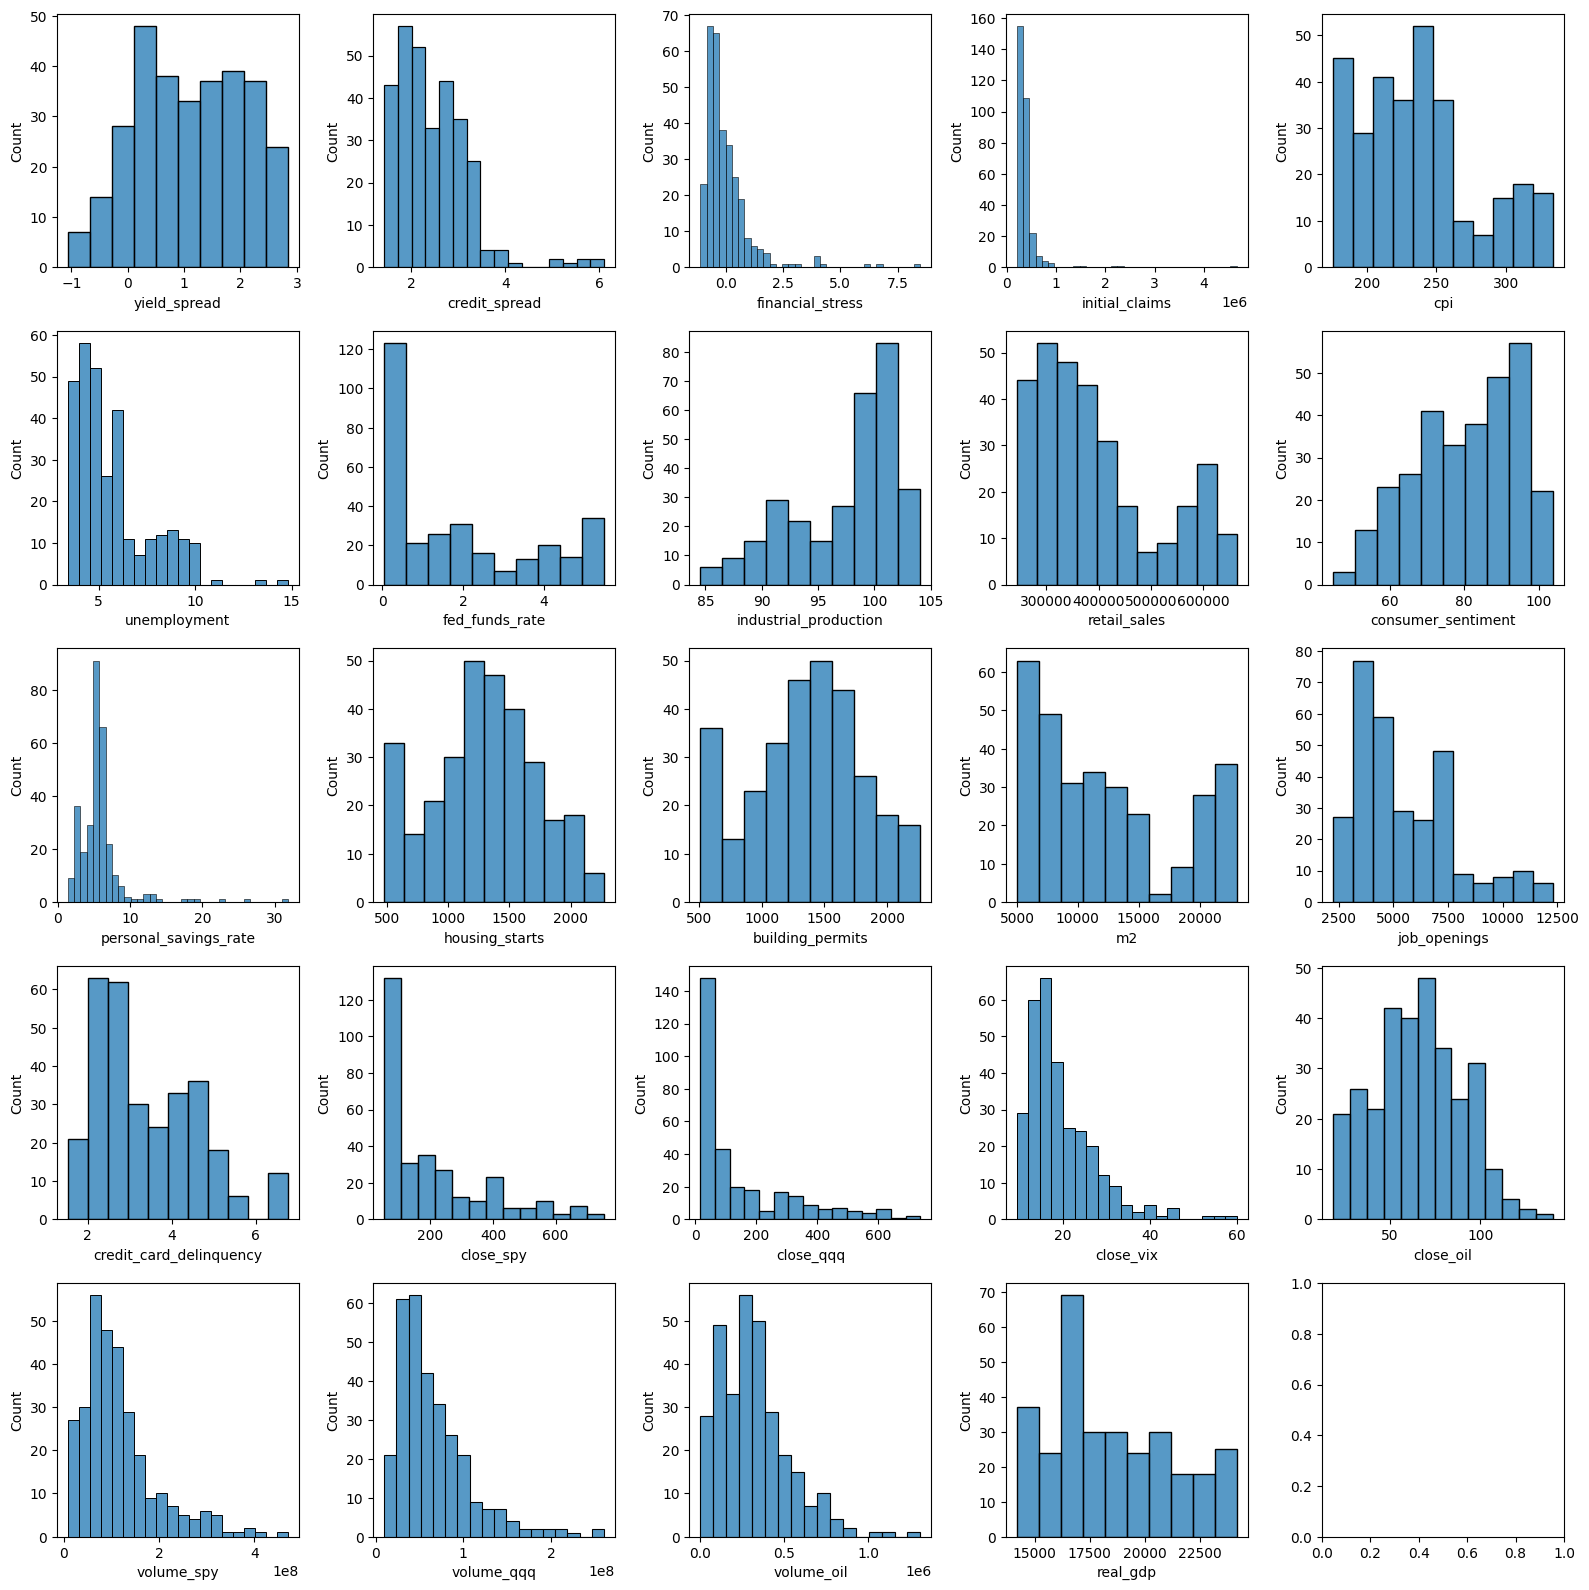

In [16]:
# Let's also make a histogram for each feature
f, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(16,16))
for i,col in enumerate(df.columns):
    sns.histplot(df[col], ax=axs.flatten()[i])
# for ax in axs.flatten():
#     ax.tick_params(axis='x', rotation=30)
plt.tight_layout()

From the histograms we can get an idea about the shape of the feature distributions. None of the features appear normally distributed, and we wouldn't necessarily expect them to when they are time series data with different world events impacting their values and rates of change.

Some distributions appear peaked at smaller values with some larger values occuring rarely, presumably because of market-affecting events. Examples include credit_spread, financial_stress, initial_claims, unemployment, personal_savings_rate, any volume measure, and any close measure.

Some distributions appear to be bimodal, reflecting two distinct stages for that feature. This includes:
- m2, which was redefined in 2020, greatly increasing its value, 
- retail_sales, which greatly increased after 2020
- cpi, reflecting the large impact that COVID spending had on inflation. In an ideal world, this histogram would be continuous, reflecting a consistent rate of inflation over time.

### 2.2: Correlation matrix

In [17]:
# Let's also add in future GDP values, to get an idea of how each feature affects market conditions in the future
future_gdps = {
    "real_gdp_change_{}mo".format(i): df["real_gdp"].shift(periods=-i) - df["real_gdp"]
        for i in range(6,60+1,6)
}

df_fut_gdps = df.copy()
for name, val in future_gdps.items():
    df_fut_gdps[name] = val

df_fut_gdps.head(5).iloc[:,:-1]

,yield_spread,credit_spread,financial_stress,initial_claims,cpi,unemployment,fed_funds_rate,industrial_production,retail_sales,consumer_sentiment,...,real_gdp,real_gdp_change_6mo,real_gdp_change_12mo,real_gdp_change_18mo,real_gdp_change_24mo,real_gdp_change_30mo,real_gdp_change_36mo,real_gdp_change_42mo,real_gdp_change_48mo,real_gdp_change_54mo
2001-02-28,0.51,2.88,0.437625,371250.0,175.6,4.2,5.49,91.9020,247339.0,94.7,...,14229.765,41.929,23.809,231.083,307.815,513.802,932.995,1137.085,1441.115,1693.017
2001-03-31,0.75,3.04,0.675540,387200.0,176.0,4.2,5.31,91.3034,247289.0,90.6,...,14183.120,31.396,189.665,336.513,431.021,805.662,1065.560,1329.499,1661.607,1864.467
2001-04-30,1.05,2.73,0.800700,396750.0,176.1,4.3,4.80,91.1162,244514.0,91.5,...,14183.120,31.396,189.665,336.513,431.021,805.662,1065.560,1329.499,1661.607,1864.467
2001-05-31,1.21,2.65,0.387725,394500.0,176.4,4.4,4.21,90.7891,249113.0,88.4,...,14183.120,31.396,189.665,336.513,431.021,805.662,1065.560,1329.499,1661.607,1864.467
2001-06-30,1.17,2.65,0.420820,397200.0,177.3,4.3,3.97,90.3555,250250.0,92.0,...,14271.694,-18.120,189.154,265.886,471.873,891.066,1095.156,1399.186,1651.088,1865.040


In [18]:
corr_mat = df_fut_gdps.corr()

<Figure size 1000x1000 with 0 Axes>

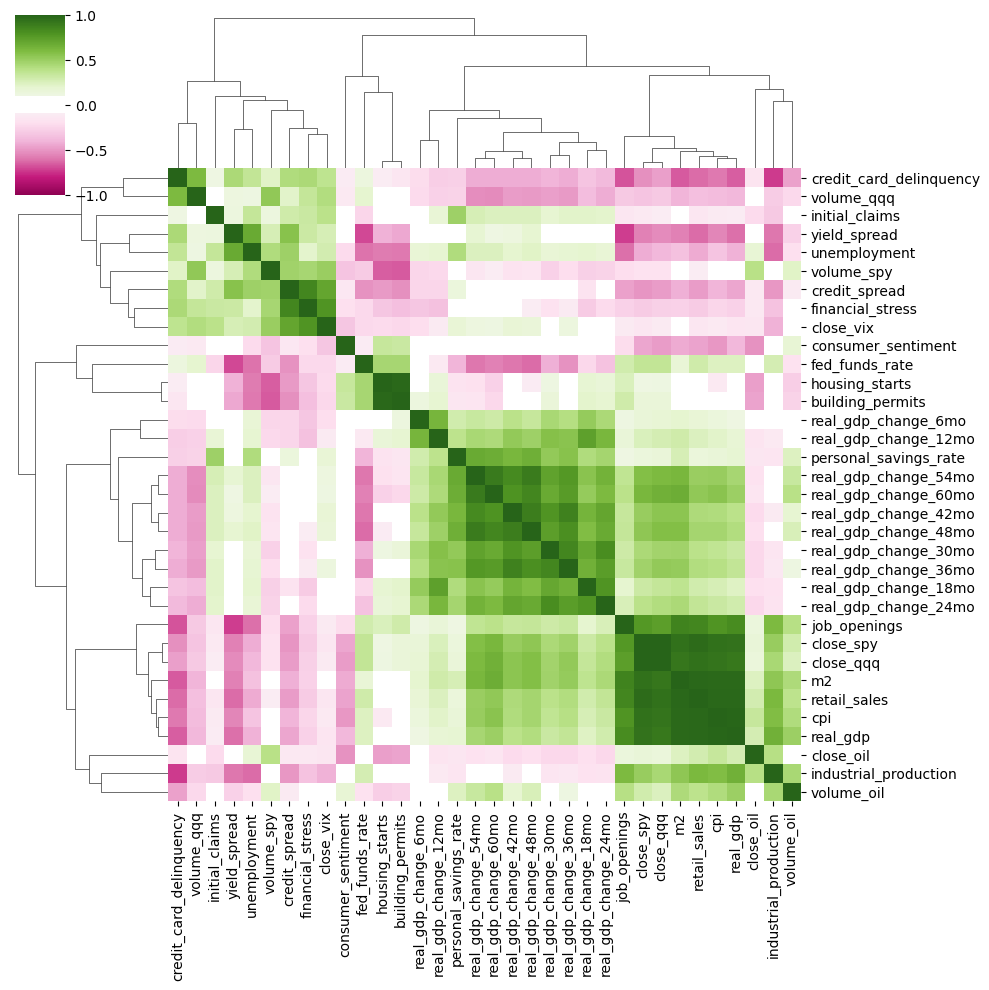

In [19]:
plt.figure(figsize=(10,10))

colors = plt.get_cmap("PiYG", 256)(np.linspace(0,1,256))
# cmap = sns.color_palette("PiYG", as_cmap=True)
colors[128-12:128+13,:] = 0
cmap = matplotlib.colors.ListedColormap(colors)

# sns.heatmap(corr_mat, vmin=-1, vmax=1, center = 0, cmap = cmap)
sns.clustermap(corr_mat, vmin=-1, vmax=1, center = 0, cmap = cmap)
# plt.tight_layout()

This is a very interesting figure, as it shows how the features I've captured correlate with each other. Any feature that correlates with future GDP values (the first ~10 features plot along the axis here) will have predictive power in predicting future market health. I have performed hierarchical clustering on the feature correlation profiles so that those with similar correlation profiles are grouped together. These groups are likely highly colinear and so provide similar information to each other.

Something interesting here is that personal_savings_rate has a feature correlation profile that matches future GDP changes particularly well, which might hint at it being an effective predictor of future market health.

Let's plot the personal_savings_rate with future gdp values.

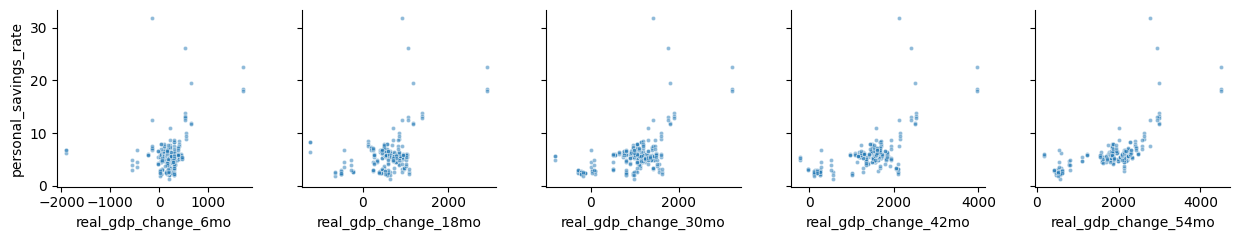

In [20]:
sns.pairplot(df_fut_gdps, y_vars=["personal_savings_rate"], x_vars=list(future_gdps.keys())[0:10:2], plot_kws={'alpha':0.5, "marker":"."})
plt.tight_layout()

We can see that there really is a positive correlation here, with high personal savings rates predicting large changes to gdp. I will caution saying that it is an amazing predictor, however, because the particularly high personal_savings_rates are from a very rare event, namely the covid pandemic lockdown, which resulted in many people recieving governmental help and there being less to do / buy. The GDP also went down at the same time, meaning that after a correction when lockdowns lifted, GDP values went back to near pre-pandemic levels, greatly increasing GDP delta values. Even then, though, the positive correlaiton appears to hold for smaller savings rate values on longer term GDP growth.

Let's try recreating the correlation matrix with the personal savings rate extremes atrifically being brought back down


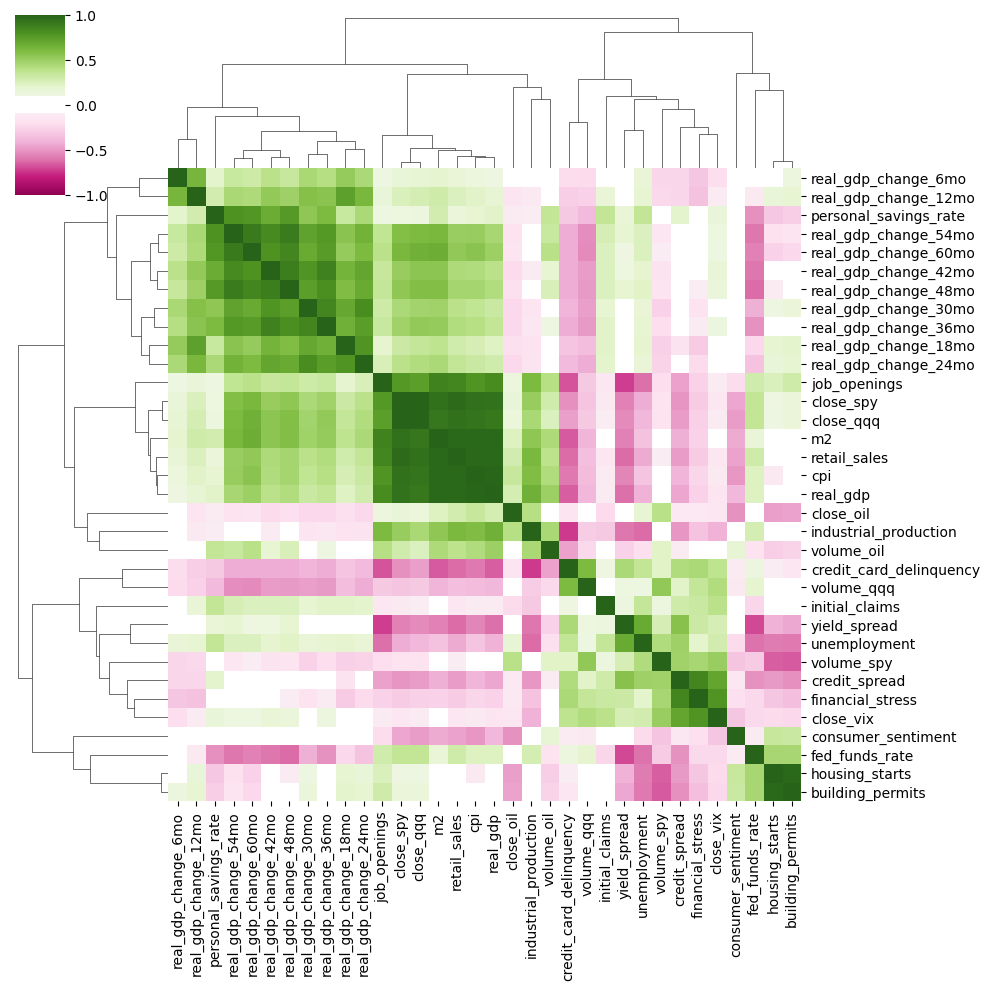

In [21]:
df_temp = df_fut_gdps.copy()
df_temp["personal_savings_rate"] = [i if i<10 else 10 for i in df_temp["personal_savings_rate"]]

corr_mat_temp = df_temp.corr()
sns.clustermap(corr_mat_temp, vmin=-1, vmax=1, center = 0, cmap = cmap)

From this we can see that the personal_savings_rate still correlates strongly with changes to future GDP values, but less than originally predicted and the correlation grows stronger for GDP values farther in the future. It appears to be about as good as a predictor as many other features, and so from now on I will not pay special attention to it.

Now, I'm also interested in predicting future QQQ values, as accurately predicting these would be a very handy investment tool.

Let's calculate the percent change in qqq from the current value to the value one month into the future. If any of the features correlate with this value then in theory we should be able to predict future qqq values relatively well.

In [22]:
df_qqq_change = df.copy()
qqq_change = df_qqq_change['close_qqq'].pct_change().shift(-1)
df_qqq_change["qqq_pct_change"] = qqq_change
df_qqq_change.head()

,yield_spread,credit_spread,financial_stress,initial_claims,cpi,unemployment,fed_funds_rate,industrial_production,retail_sales,consumer_sentiment,...,credit_card_delinquency,close_spy,close_qqq,close_vix,close_oil,volume_spy,volume_qqq,volume_oil,real_gdp,qqq_pct_change
2001-02-28,0.51,2.88,0.437625,371250.0,175.6,4.2,5.49,91.9020,247339.0,94.7,...,4.81,78.485298,39.983036,28.350000,27.420000,14825800.0,102187900.0,82364.0,14229.765,-0.174921
2001-03-31,0.75,3.04,0.675540,387200.0,176.0,4.2,5.31,91.3034,247289.0,90.6,...,4.81,74.087158,32.989159,28.639999,26.400000,9183600.0,63661300.0,63947.0,14183.120,0.178800
2001-04-30,1.05,2.73,0.800700,396750.0,176.1,4.3,4.80,91.1162,244514.0,91.5,...,4.81,80.417152,38.887619,25.480000,28.459999,10766900.0,73859100.0,40223.0,14183.120,-0.030769
2001-05-31,1.21,2.65,0.387725,394500.0,176.4,4.4,4.21,90.7891,249113.0,88.4,...,4.94,79.966370,37.691078,22.639999,28.370001,9874200.0,68018300.0,101694.0,14183.120,0.021686
2001-06-30,1.17,2.65,0.420820,397200.0,177.3,4.3,3.97,90.3555,250250.0,92.0,...,4.94,78.060844,38.508430,19.059999,26.250000,9824200.0,59719600.0,86303.0,14271.694,-0.086214


Text(0.5, 1.0, 'Monthly QQQ % change with major market events')

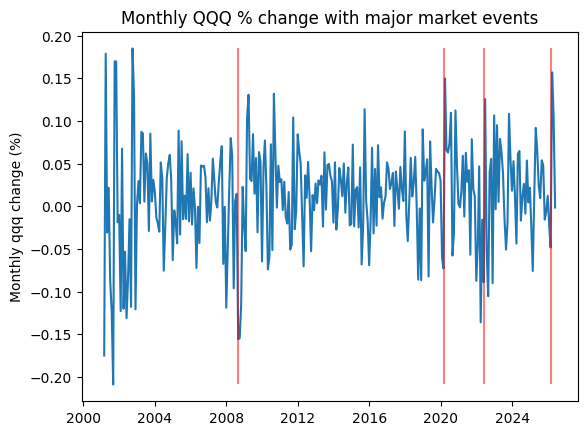

In [23]:
col = "qqq_pct_change"
plt.figure()
sns.lineplot(df_qqq_change[col])
plt.vlines(POINTS_OF_INTEREST, df_qqq_change[col].min(), df_qqq_change[col].max(), color='r', linestyle="-", alpha=0.5)
plt.ylabel("Monthly qqq change (%)")
plt.title("Monthly QQQ % change with major market events")

Let's recreate the correlation matrix and see if any features are predictive of next month's qqq value.

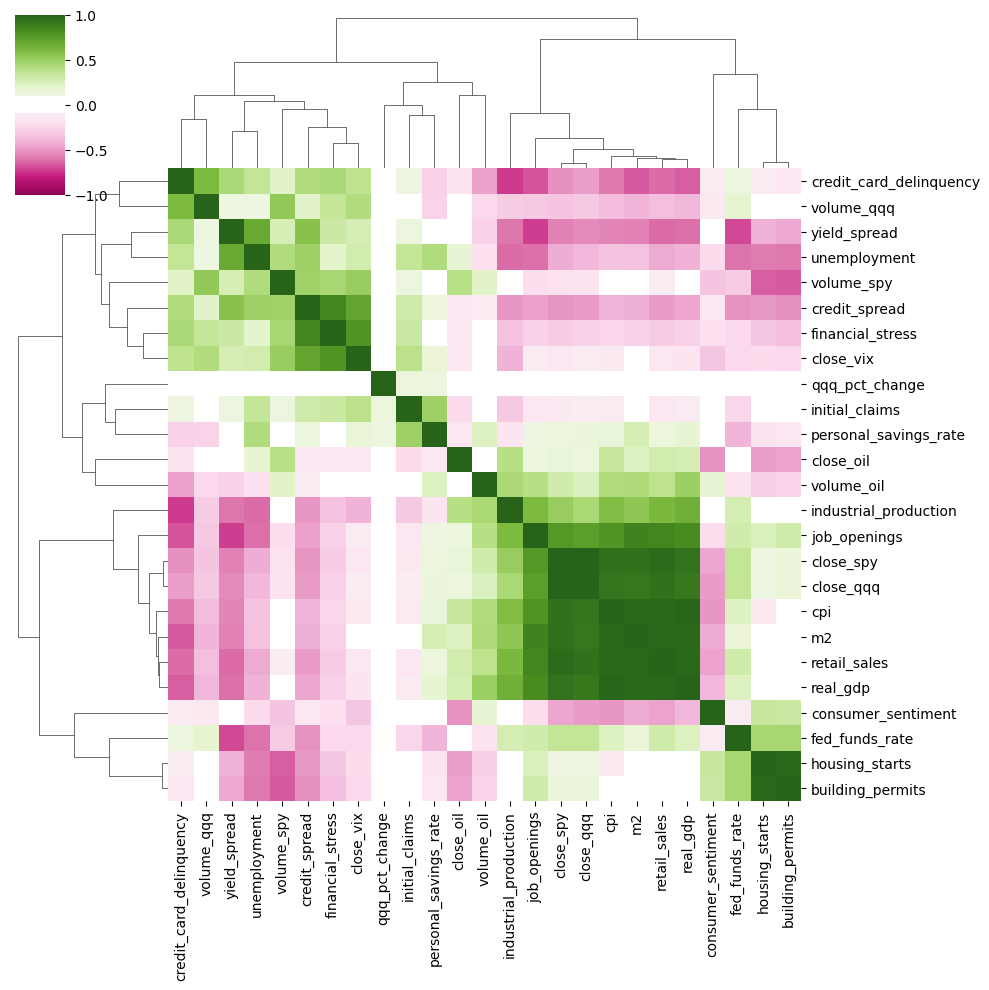

In [24]:
corr_mat = df_qqq_change.corr()
sns.clustermap(corr_mat, vmin=-1, vmax=1, center = 0, cmap = cmap)

Wow! Fascinating that nearly all features are not predictive of qqq_pct_change at all, with only initial_claims and personal_savings_rate being slighly predictive. That makes sense given that anything with predictive value would presumably already be used to price the current qqq value, nullifying its predictive power. This means that any predictor I create may not perform well, but if I can get it to perform slightly better than a buy-and-hold strategy, then that would be remarkable.

Let's do the same thing again but using longer change periods.

In [25]:
change_periods = [2,3,6,12]

for cp in change_periods:
    qqq_change = df_qqq_change['close_qqq'].pct_change(periods=cp).shift(-cp)
    df_qqq_change["qqq_pct_change_{}mo".format(cp)] = qqq_change

# qqq_change_6mo = df['close_qqq'].pct_change(periods=6).shift(-6)
# df["qqq_pct_change_6mo"] = qqq_change_6mo
# qqq_change_12mo = df['close_qqq'].pct_change(periods=12).shift(-12)
# df["qqq_pct_change_12mo"] = qqq_change_12mo
df_qqq_change.head()

,yield_spread,credit_spread,financial_stress,initial_claims,cpi,unemployment,fed_funds_rate,industrial_production,retail_sales,consumer_sentiment,...,close_oil,volume_spy,volume_qqq,volume_oil,real_gdp,qqq_pct_change,qqq_pct_change_2mo,qqq_pct_change_3mo,qqq_pct_change_6mo,qqq_pct_change_12mo
2001-02-28,0.51,2.88,0.437625,371250.0,175.6,4.2,5.49,91.9020,247339.0,94.7,...,27.420000,14825800.0,102187900.0,82364.0,14229.765,-0.174921,-0.027397,-0.057323,-0.228029,-0.288093
2001-03-31,0.75,3.04,0.675540,387200.0,176.0,4.2,5.31,91.3034,247289.0,90.6,...,26.400000,9183600.0,63661300.0,63947.0,14183.120,0.178800,0.142529,0.167306,-0.259770,-0.078927
2001-04-30,1.05,2.73,0.800700,396750.0,176.1,4.3,4.80,91.1162,244514.0,91.5,...,28.459999,10766900.0,73859100.0,40223.0,14183.120,-0.030769,-0.009751,-0.095125,-0.265439,-0.312459
2001-05-31,1.21,2.65,0.387725,394500.0,176.4,4.4,4.21,90.7891,249113.0,88.4,...,28.370001,9874200.0,68018300.0,101694.0,14183.120,0.021686,-0.066398,-0.181087,-0.113570,-0.328415
2001-06-30,1.17,2.65,0.420820,397200.0,177.3,4.3,3.97,90.3555,250250.0,92.0,...,26.250000,9824200.0,59719600.0,86303.0,14271.694,-0.086214,-0.198468,-0.365865,-0.148578,-0.428884


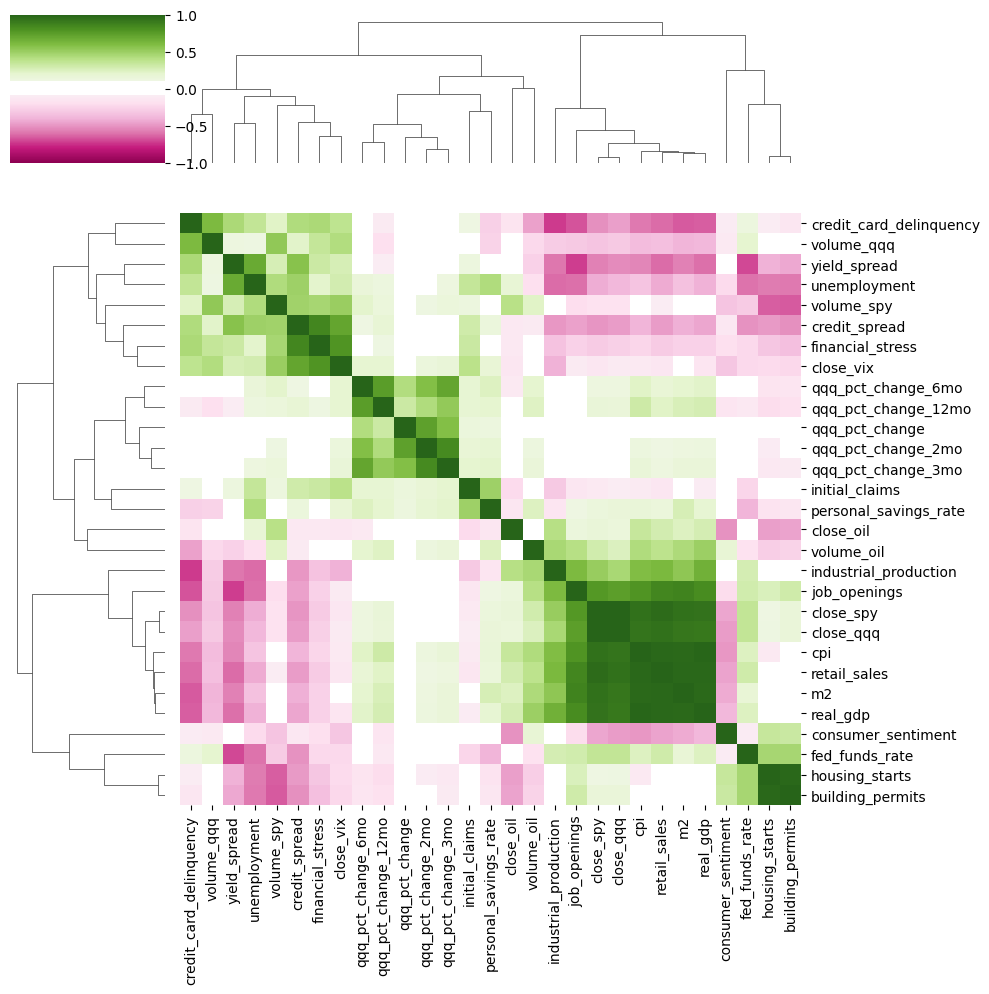

In [26]:
corr_mat = df_qqq_change.corr()
sns.clustermap(corr_mat, vmin=-1, vmax=1, center = 0, cmap = cmap)
plt.tight_layout()

A few more features become more correlated to changes of qqq over a longer period, but still nothing too strong. It may be difficult creating any sort of predictor with this given data, which makes sense. Still, let's be concrete about this by plotting just the correlation values of the macro features with the percent changes to qqq over different timescales.

<Axes: >

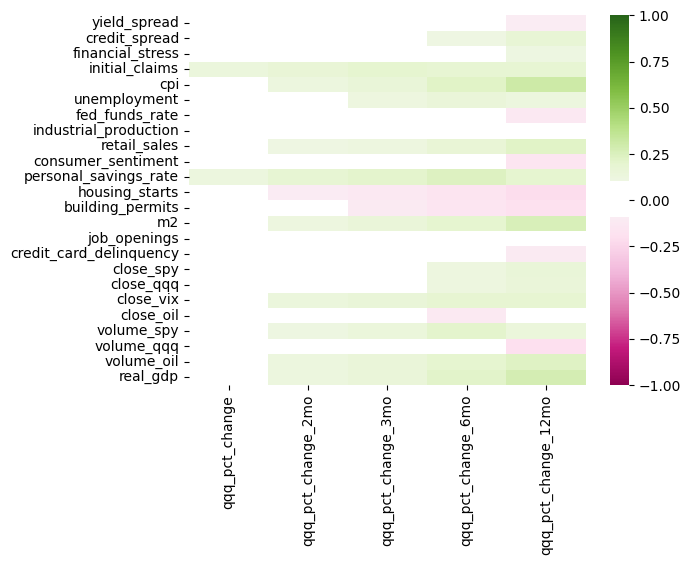

In [27]:
horizons = ['qqq_pct_change', 'qqq_pct_change_2mo', 'qqq_pct_change_3mo', 
            'qqq_pct_change_6mo', 'qqq_pct_change_12mo']
macro_features = df.columns.to_list()
corr_summary = df_qqq_change[macro_features + horizons].corr()[horizons].drop(horizons)
sns.heatmap(corr_summary, vmin=-1, vmax=1, center=0, cmap=cmap)

### 2.3 PCA